## Load Data

In [2]:

#! pip install mne

# NumPy handles arrays and vectorized math.
import numpy as np
# Matplotlib is used for all figures in the notebook.
import matplotlib.pyplot as plt
# Gridspec is available for custom figure layouts if needed later.
import matplotlib.gridspec as gridspec
# Pandas stores tables and makes grouping / pivoting easier.
import pandas as pd
# Path can help with file paths if you save or load from disk later.
from pathlib import Path
# These helpers come from your project code.
# - load_eeg_data loads epochs for one subject / condition / ROI
# - CHANNEL_GROUPS and FREQ_BANDS store predefined channel and band definitions
from utils import load_eeg_data, CHANNEL_GROUPS, FREQ_BANDS

# Analyze the BLA subjects used throughout the notebook.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# Show plots inline in Jupyter.
%matplotlib inline
# Slightly increase default display quality and font size.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Fixed analysis settings used by the later cells.
CONDITION = "BLA"
CHANNELS = "BLA"   # T7, T8, TP7, TP8
FREQ_RANGE_LABEL = "delta_gamma"

# Define the baseline window requested by you.
# All baseline-centering in this notebook uses this exact time range.
BASELINE_TMIN = -0.500
BASELINE_TMAX = -0.050
BASELINE_LABEL = "-500 ms to -50 ms"

import warnings
import contextlib
import io

# Store the loaded epochs and raw data for quick checking.
all_epochs = {}
all_data = {}
loaded_subjects = []
failed_subjects = []

# Load each subject once so we know the files are readable before later analysis cells.
for SUBJECT_ID in SUBJECTS:
    try:
        # Suppress extra warnings / prints from helper functions so the notebook stays readable.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    SUBJECT_ID,
                    channels=CHANNELS,
                    freq_band=FREQ_RANGE_LABEL
                )

        # Convert to microvolts for easier interpretation when inspecting raw values.
        data = epochs.get_data() * 1e6

        # Save the loaded objects.
        all_epochs[SUBJECT_ID] = epochs
        all_data[SUBJECT_ID] = data
        loaded_subjects.append(SUBJECT_ID)

    except Exception as e:
        failed_subjects.append((SUBJECT_ID, str(e)))

print("Loaded successfully:", loaded_subjects)

if failed_subjects:
    print("\nFailed to load:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Loaded successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


## Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLA trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (14 subjects)

In [3]:

# Test the function import.
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Re-state the main analysis settings used below.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
CONDITION = "BLA"
CHANNELS = "BLA"

# The rolling window is only for the thick smoothed trend line.
# It does NOT change the raw trial values or the SEM.
ROLLING_WINDOW = 5

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline window used for centering: {BASELINE_LABEL}")

# Helper: convert a trial x band absolute-power table into relative power (%).
# For each row (one trial), we divide each band's power by the total power across bands.
def compute_relative_power_pivot(power_pivot, bands):
    power_pivot = power_pivot.reindex(columns=bands)
    total_power_per_trial = power_pivot.sum(axis=1)
    return power_pivot.div(total_power_per_trial, axis=0) * 100


Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline window used for centering: -500 ms to -50 ms


In [4]:

import warnings
import contextlib
import io

# These dictionaries keep both:
# 1) the raw power measured over the analysis window
# 2) the baseline power measured over -500 to -50 ms
# 3) the centered power = analysis-window power minus baseline power
all_power_dfs = {}
all_power_pivots_raw = {}
all_power_pivots = {}
all_baseline_power_pivots = {}
all_psds_dicts = {}
processed_subjects = []
failed_subjects = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        # Compute absolute band power over the full epoch used in the original plot.
        power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Compute absolute band power only inside the requested baseline window.
        epochs_baseline = epochs.copy().crop(tmin=BASELINE_TMIN, tmax=BASELINE_TMAX)
        baseline_df, _ = compute_frequency_power(epochs_baseline, fmin=0.5, fmax=45)

        # Pivot so rows = trials and columns = bands.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Do the exact same reshaping for the baseline window.
        baseline_pivot = (
            baseline_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Center absolute power by subtracting the average baseline power for the same trial and band.
        # After this subtraction:
        #   0   means "equal to baseline"
        #   >0  means "above baseline"
        #   <0  means "below baseline"
        power_pivot_centered = power_pivot_raw - baseline_pivot

        all_power_dfs[subject_id] = power_df
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_power_pivots[subject_id] = power_pivot_centered
        all_baseline_power_pivots[subject_id] = baseline_pivot
        all_psds_dicts[subject_id] = psds_dict
        processed_subjects.append(subject_id)

    except Exception as e:
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


# BLA Frequency Domain Absolute Power All Times

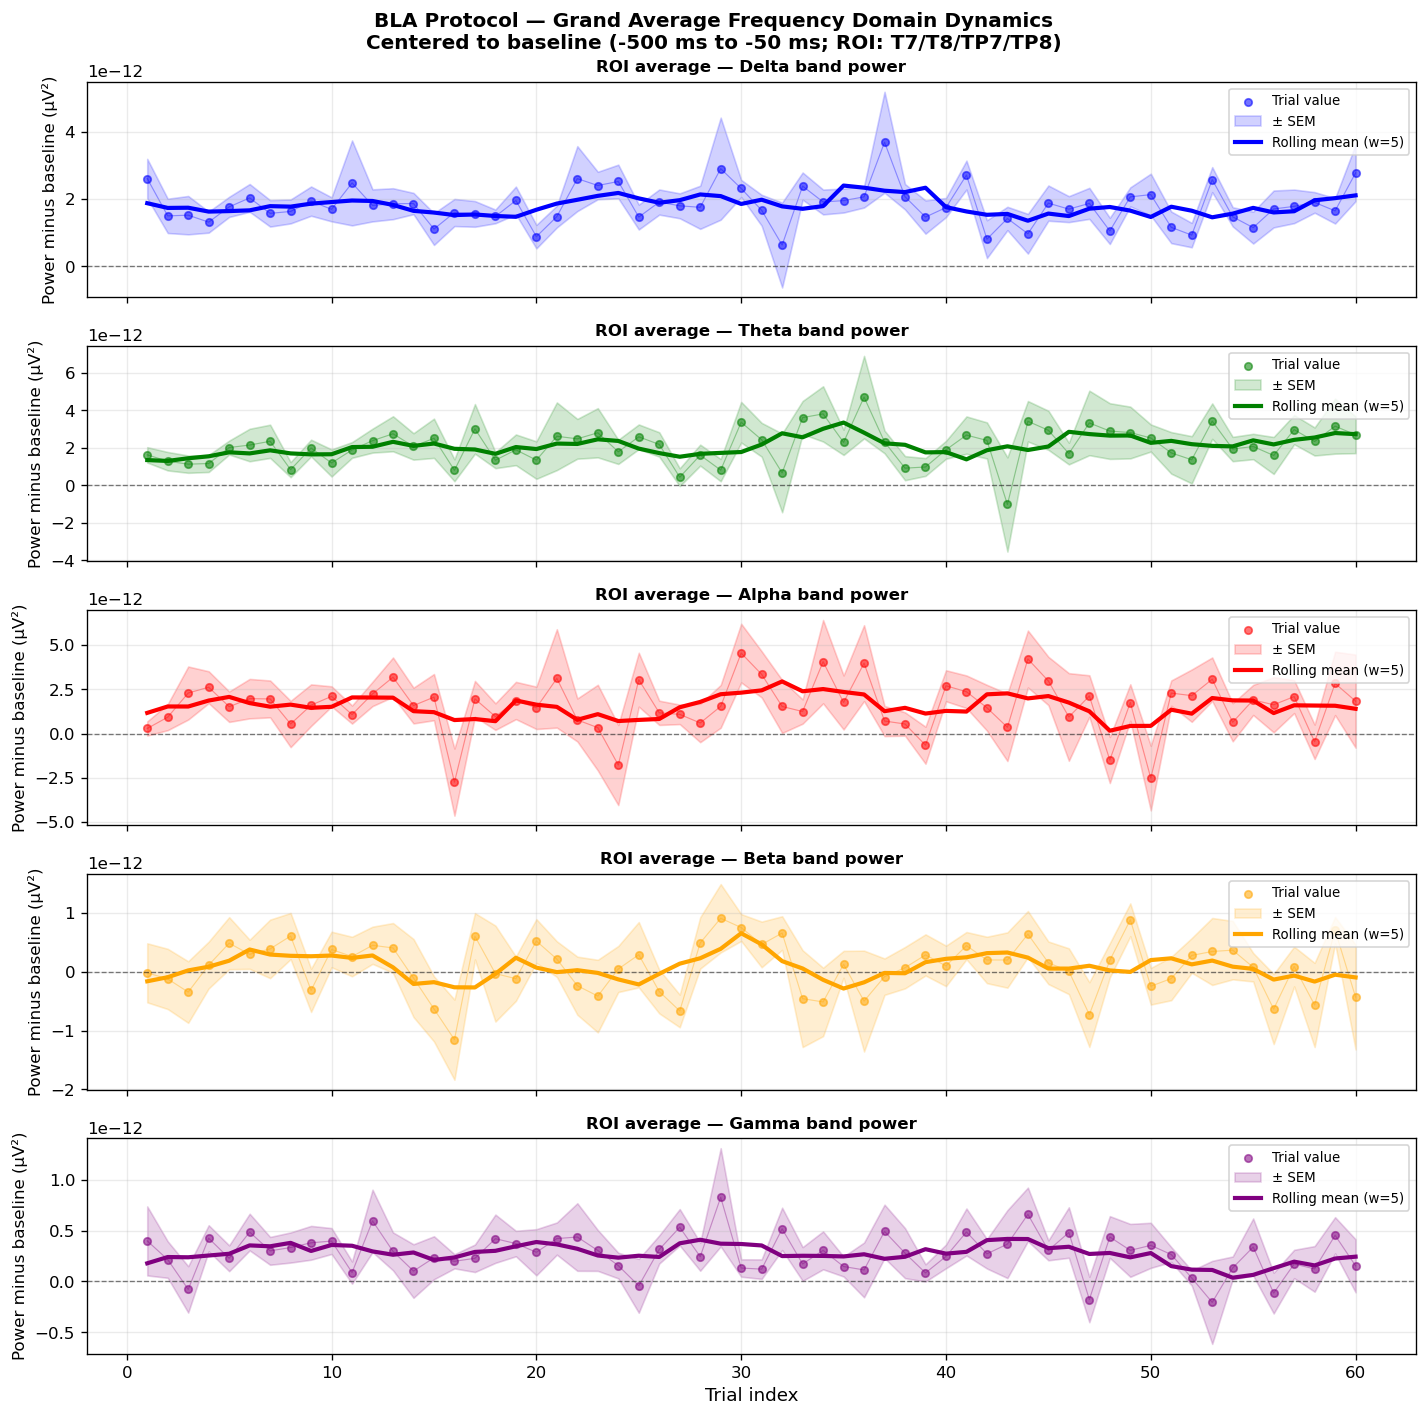

Figure saved: frequency_dynamics_BLA_grand_average.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Values above 0 are above baseline. Values below 0 are below baseline.


In [5]:

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Build the grand-average centered power table across subjects.
# Each column in band_df is one subject.
# Each row is one trial index.
grand_power = {}
grand_sem = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects:
        power_pivot = all_power_pivots[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power[band] = band_df.mean(axis=1)
        grand_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power:
        values = grand_power[band].values
        errors = grand_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Scatter = grand-average value at each trial index.
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        # Thin line just connects the same values visually.
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # SEM = standard error of the mean across subjects.
        # It estimates uncertainty in the grand mean at each trial index.
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling mean smooths the displayed trend but does not change the stored data.
        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus baseline (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Frequency Domain Dynamics\nCentered to baseline ({BASELINE_LABEL}; ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)
fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average.png")
print(f"Analysis completed for subjects: {processed_subjects}")
print("Values above 0 are above baseline. Values below 0 are below baseline.")


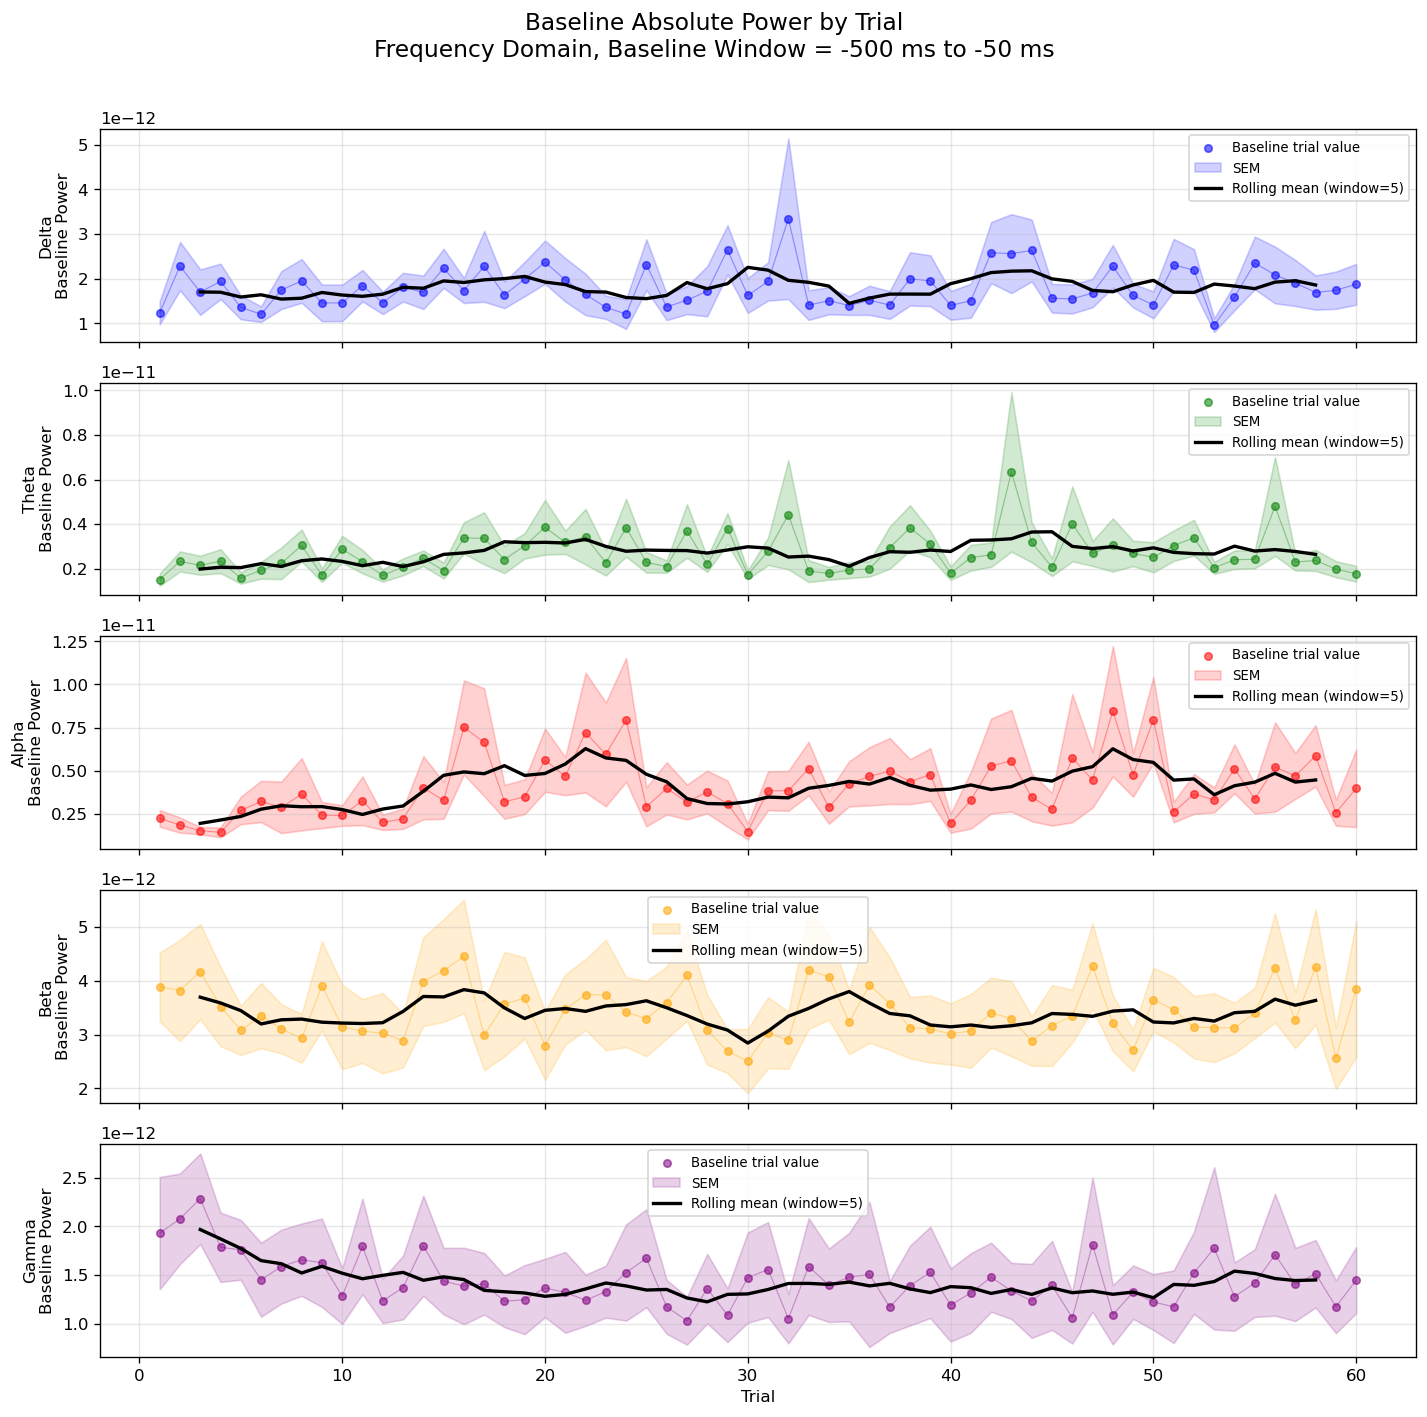

In [6]:
# --- Plot baseline-only absolute power for each trial (frequency-domain, all-times analysis) ---

# Import NumPy so we can build simple numeric arrays such as the trial-number axis.
import numpy as np

# Import pandas because we will combine subject-level trial series into tables
# and use rolling-window smoothing for the trend line.
import pandas as pd

# Import matplotlib so we can make the actual figure.
import matplotlib.pyplot as plt

# Define the EEG frequency bands we want to plot.
# These names should match the column names used in all_baseline_power_pivots.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# Choose one plotting color for each band so the subplots are easy to distinguish.
# The order here matches the order of bands above.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Create a dictionary that will eventually hold the grand-average baseline power
# for each band.
#
# More specifically:
# - key   = band name such as 'alpha'
# - value = a pandas Series whose entries are the mean baseline power at trial 1,
#           trial 2, trial 3, etc., after averaging across subjects
grand_baseline_power = {}

# Create a second dictionary that will hold the SEM for each band.
#
# SEM = standard error of the mean.
# It tells us how much uncertainty there is in the across-subject mean at each trial.
# The formula used later is:
#
#     SEM = standard deviation across subjects / sqrt(number of subjects)
#
# Smaller SEM means the subjects are more similar to each other at that trial.
grand_baseline_sem = {}

# Loop through the frequency bands one at a time so we can build a separate
# across-subject baseline-power curve for delta, theta, alpha, beta, and gamma.
for band in bands:

    # Start an empty list that will collect one subject-level trial series at a time.
    #
    # After this inner loop finishes, band_trials will look conceptually like:
    # [
    #   subject_1 baseline values across trials,
    #   subject_2 baseline values across trials,
    #   subject_3 baseline values across trials,
    #   ...
    # ]
    #
    # Each entry is one vector for the current band only.
    band_trials = []

    # Loop over every subject that successfully made it through the earlier
    # "all times" frequency-domain baseline computation.
    for subject_id in processed_subjects:

        # Pull out this subject's baseline absolute-power table.
        #
        # Expected structure:
        # - rows    = trials
        # - columns = frequency bands
        #
        # So if we later ask for baseline_pivot['alpha'], we get this subject's
        # alpha-band baseline power for every trial.
        baseline_pivot = all_baseline_power_pivots[subject_id]

        # Only continue if this band is actually present as a column.
        # This protects the code in case one subject is missing a band for some reason.
        if band in baseline_pivot.columns:

            # Extract the current band's values across trials for this subject.
            #
            # reset_index(drop=True) removes the original index labels and replaces them
            # with 0, 1, 2, ...
            #
            # That matters because when we later concatenate different subjects side by side,
            # we want the rows to align purely by trial order, not by any old index labels
            # that might differ from subject to subject.
            band_trials.append(baseline_pivot[band].reset_index(drop=True))

    # Only compute the grand average if at least one subject contributed data
    # for this band.
    if band_trials:

        # Concatenate the subject vectors side by side into one DataFrame.
        #
        # After this step:
        # - each column = one subject
        # - each row    = one trial index
        #
        # Example idea:
        #
        #            subj1   subj2   subj3
        # trial 1     ...
        # trial 2     ...
        # trial 3     ...
        band_df = pd.concat(band_trials, axis=1)

        # Compute the mean across subjects for each trial.
        #
        # axis=1 means "go across columns within each row."
        # Since columns are subjects, this gives the mean subject value at each trial.
        #
        # Mathematically, for a fixed trial t:
        #
        #   mean_t = (x_1t + x_2t + ... + x_Nt) / N
        #
        # where x_it is the baseline power for subject i at trial t.
        grand_baseline_power[band] = band_df.mean(axis=1)

        # Compute the standard error of the mean (SEM) across subjects at each trial.
        #
        # band_df.std(axis=1) gives the standard deviation across subjects for each trial.
        # Dividing by sqrt(number of subjects) converts that standard deviation into SEM.
        #
        # So for each trial:
        #
        #   SEM_t = SD_t / sqrt(N)
        #
        # This is what we will use for the shaded uncertainty region in the plot.
        grand_baseline_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Create one subplot per band.
#
# len(bands) gives five stacked panels.
# figsize sets the overall figure size in inches.
# sharex=True means all panels use the same x-axis, which is helpful because
# every subplot is indexed by trial number.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

# Loop through the bands again, but now for plotting.
#
# enumerate gives us:
# - i      = subplot number (0, 1, 2, ...)
# - band   = current band name
# - color  = matching plotting color
for i, (band, color) in enumerate(zip(bands, colors)):

    # Select the subplot axis for this band.
    ax = axes[i]

    # Only plot if we successfully computed a grand-average series for this band.
    if band in grand_baseline_power:

        # Pull the mean baseline power values into a NumPy array.
        # Each entry corresponds to one trial.
        values = grand_baseline_power[band].values

        # Pull the SEM values into a NumPy array.
        # These have the same length as values and give the vertical error size
        # at each trial.
        errors = grand_baseline_sem[band].values

        # Create the x-axis as trial numbers 1, 2, 3, ... instead of Python's
        # usual 0-based indexing.
        trial_idx = np.arange(1, len(values) + 1)

        # Plot the trial-by-trial grand-average baseline power as points.
        #
        # Why scatter points?
        # Because each point represents one discrete trial average, so points make
        # the raw trial-wise values easy to see.
        #
        # s controls marker size.
        # alpha adds transparency so the plot looks less harsh.
        # zorder controls which layers appear on top of others.
        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Baseline trial value'
        )

        # Add a faint line connecting the trial points in order.
        #
        # This does not smooth the data; it just visually links neighboring trials
        # so gradual upward or downward drift is easier to notice.
        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        # Add a shaded SEM band around the grand mean.
        #
        # The lower bound is mean - SEM.
        # The upper bound is mean + SEM.
        #
        # So this shaded ribbon is a visual summary of how consistent the subjects are
        # around the mean at each trial.
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=0,
            label='SEM'
        )

        # Compute a rolling-average version of the grand-average curve.
        #
        # pd.Series(values) lets us use pandas' rolling() function.
        #
        # window=ROLLING_WINDOW means we average neighboring trials inside a moving window.
        # center=True centers that window on each trial instead of shifting it to one side.
        #
        # This does not replace the raw data; it only gives a smoother trend line.
        smoothed = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True).mean()

        # Plot the smoothed rolling-mean line in black so it stands out from the
        # band-colored raw points.
        ax.plot(
            trial_idx,
            smoothed,
            color='black',
            linewidth=2,
            label=f'Rolling mean (window={ROLLING_WINDOW})'
        )

    # Label the y-axis with the current band name so each subplot is self-contained.
    ax.set_ylabel(f'{band.capitalize()}\nBaseline Power')

    # Add a light background grid.
    # This makes it easier to compare trial-to-trial height changes by eye.
    ax.grid(True, alpha=0.3)

    # Show the legend for this subplot so the viewer can identify the points,
    # SEM shading, and rolling trend line.
    ax.legend(loc='best', fontsize=8)

# Label the shared x-axis on the bottom subplot only.
axes[-1].set_xlabel('Trial')

# Add one overall title for the full stacked figure.
#
# BASELINE_LABEL is included so the figure reminds you exactly which baseline window
# was used to compute these values.
fig.suptitle(
    'Baseline Absolute Power by Trial\n'
    f'Frequency Domain, Baseline Window = {BASELINE_LABEL}',
    fontsize=14
)

# Tighten the spacing so subplots do not overlap, while leaving a little room
# at the top for the main title.
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Render the figure to the notebook output.
plt.show()


# BLA Frequency Domain Absolute Power 0-500ms

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully (0–500 ms): [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


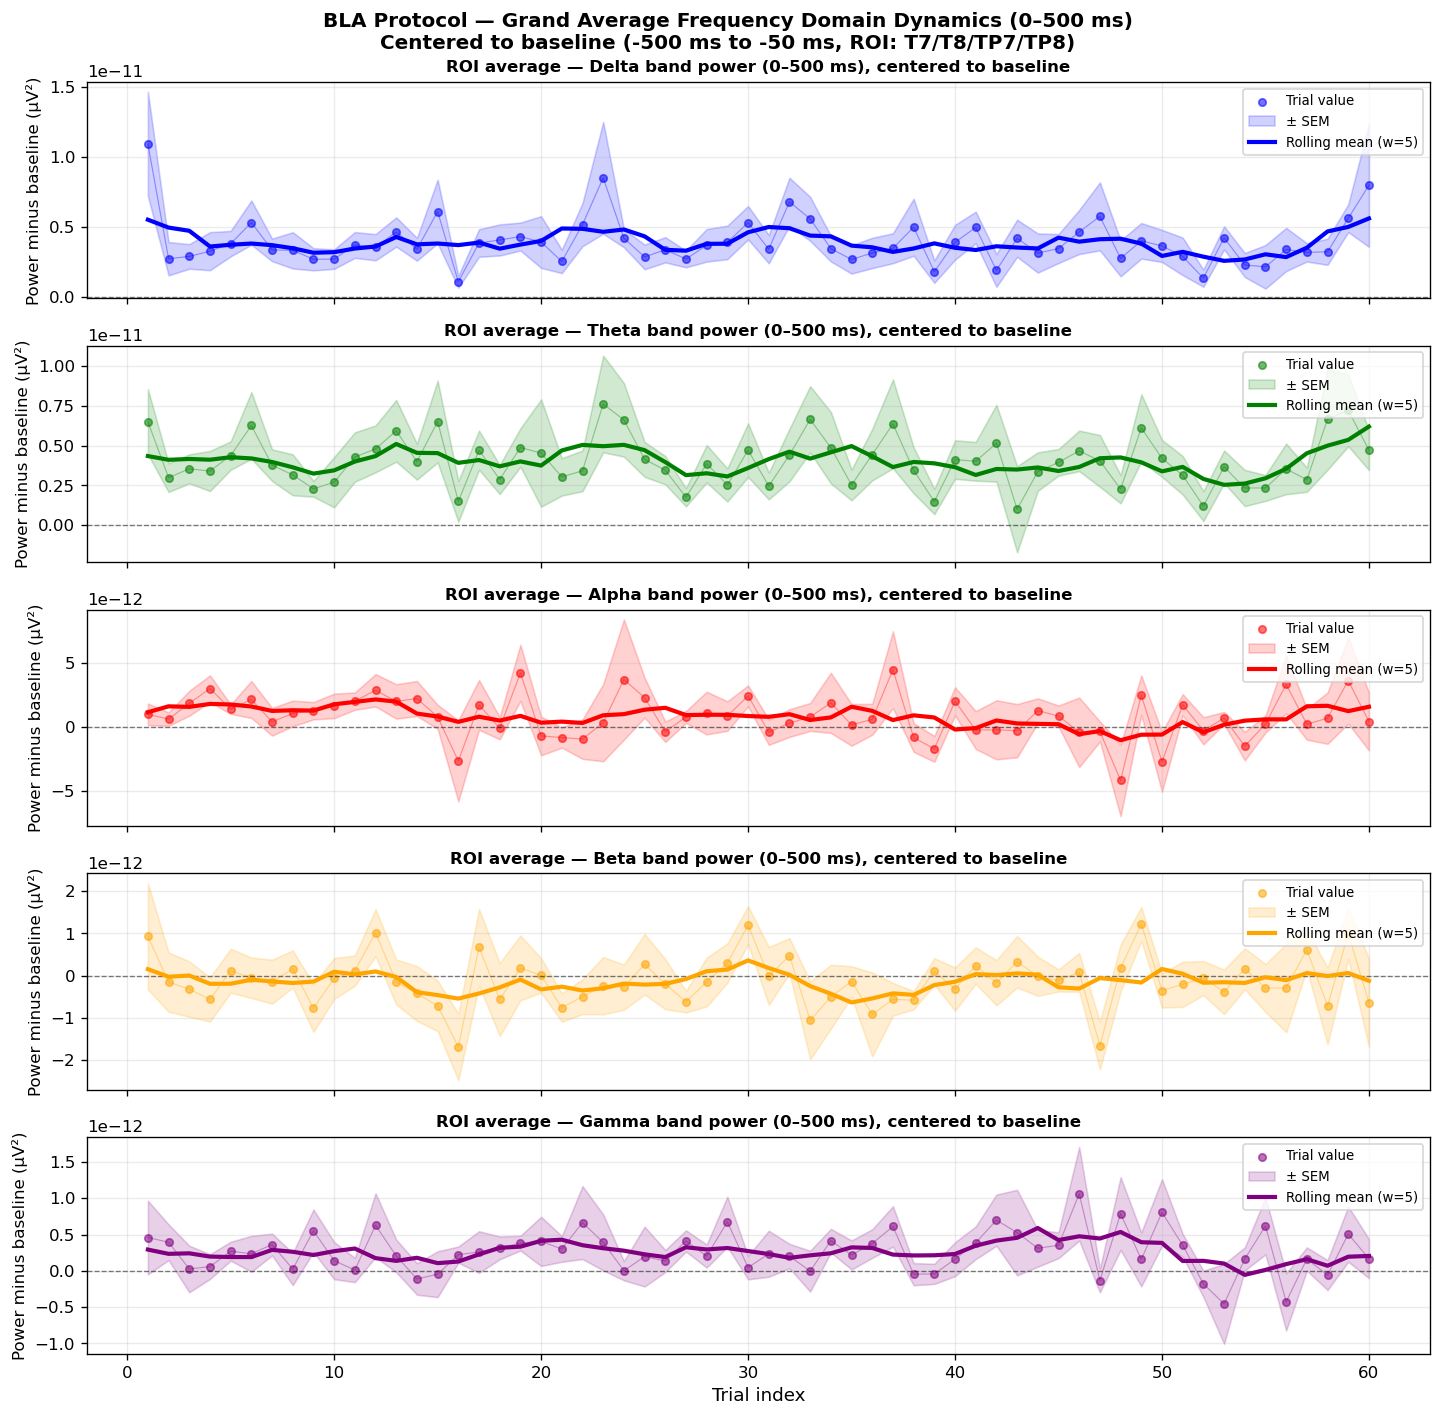

Figure saved: frequency_dynamics_BLA_grand_average_0_500ms.png


In [7]:

# --- Frequency-domain absolute power using only 0–500 ms, then centering to baseline ---

import warnings
import contextlib
import io

all_power_dfs_0_500ms = {}
all_power_pivots_raw_0_500ms = {}
all_power_pivots_0_500ms = {}
all_baseline_power_pivots_0_500ms = {}
all_psds_dicts_0_500ms = {}
processed_subjects_0_500ms = []
failed_subjects_0_500ms = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        # Keep only the requested post-stimulus window for the main measurement.
        epochs_window = epochs.copy().crop(tmin=0.0, tmax=0.5)

        # Keep the requested pre-stimulus baseline window for centering.
        epochs_baseline = epochs.copy().crop(tmin=BASELINE_TMIN, tmax=BASELINE_TMAX)

        power_df, psds_dict = compute_frequency_power(epochs_window, fmin=0.5, fmax=45)
        baseline_df, _ = compute_frequency_power(epochs_baseline, fmin=0.5, fmax=45)

        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        baseline_pivot = (
            baseline_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        power_pivot_centered = power_pivot_raw - baseline_pivot

        all_power_dfs_0_500ms[subject_id] = power_df
        all_power_pivots_raw_0_500ms[subject_id] = power_pivot_raw
        all_power_pivots_0_500ms[subject_id] = power_pivot_centered
        all_baseline_power_pivots_0_500ms[subject_id] = baseline_pivot
        all_psds_dicts_0_500ms[subject_id] = psds_dict
        processed_subjects_0_500ms.append(subject_id)

    except Exception as e:
        failed_subjects_0_500ms.append((subject_id, str(e)))

print("Processed successfully (0–500 ms):", processed_subjects_0_500ms)

if failed_subjects_0_500ms:
    print("\nFailed:")
    for subject_id, err in failed_subjects_0_500ms:
        print(f"Subject {subject_id}: {err}")

grand_power_0_500ms = {}
grand_sem_0_500ms = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_0_500ms:
        power_pivot = all_power_pivots_0_500ms[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power_0_500ms[band] = band_df.mean(axis=1)
        grand_sem_0_500ms[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_0_500ms:
        values = grand_power_0_500ms[band].values
        errors = grand_sem_0_500ms[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus baseline (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power (0–500 ms), centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Frequency Domain Dynamics (0–500 ms)\nCentered to baseline ({BASELINE_LABEL}, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average_0_500ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average_0_500ms.png")


In [8]:
# BLA Frequency Domain Absolute Power 500-1000ms

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully (500–1000 ms): [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


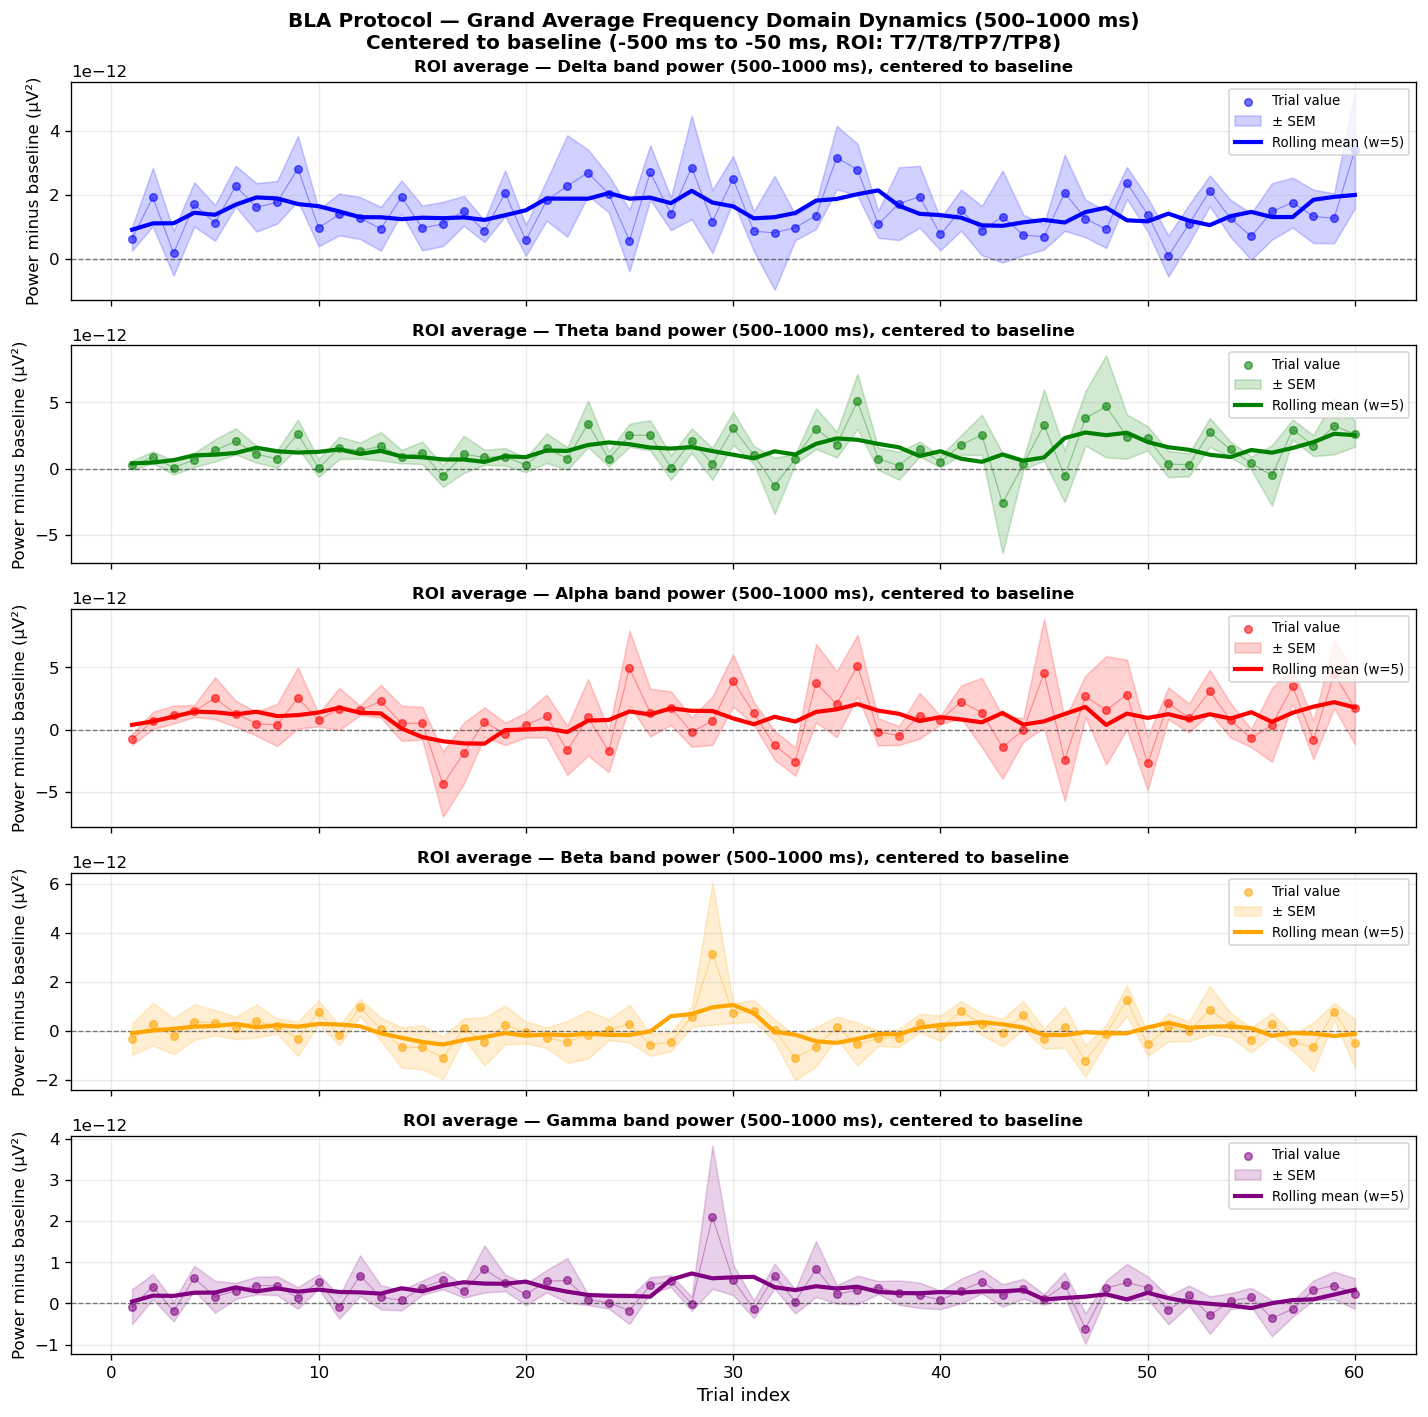

Figure saved: frequency_dynamics_BLA_grand_average_500_1000ms.png


In [9]:

# --- Frequency-domain absolute power using only 500–1000 ms, then centering to baseline ---

import warnings
import contextlib
import io

all_power_dfs_500_1000ms = {}
all_power_pivots_raw_500_1000ms = {}
all_power_pivots_500_1000ms = {}
all_baseline_power_pivots_500_1000ms = {}
all_psds_dicts_500_1000ms = {}
processed_subjects_500_1000ms = []
failed_subjects_500_1000ms = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        # Keep only the requested post-stimulus window for the main measurement.
        epochs_window = epochs.copy().crop(tmin=0.5, tmax=1.0)

        # Keep the requested pre-stimulus baseline window for centering.
        epochs_baseline = epochs.copy().crop(tmin=BASELINE_TMIN, tmax=BASELINE_TMAX)

        power_df, psds_dict = compute_frequency_power(epochs_window, fmin=0.5, fmax=45)
        baseline_df, _ = compute_frequency_power(epochs_baseline, fmin=0.5, fmax=45)

        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        baseline_pivot = (
            baseline_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        power_pivot_centered = power_pivot_raw - baseline_pivot

        all_power_dfs_500_1000ms[subject_id] = power_df
        all_power_pivots_raw_500_1000ms[subject_id] = power_pivot_raw
        all_power_pivots_500_1000ms[subject_id] = power_pivot_centered
        all_baseline_power_pivots_500_1000ms[subject_id] = baseline_pivot
        all_psds_dicts_500_1000ms[subject_id] = psds_dict
        processed_subjects_500_1000ms.append(subject_id)

    except Exception as e:
        failed_subjects_500_1000ms.append((subject_id, str(e)))

print("Processed successfully (500–1000 ms):", processed_subjects_500_1000ms)

if failed_subjects_500_1000ms:
    print("\nFailed:")
    for subject_id, err in failed_subjects_500_1000ms:
        print(f"Subject {subject_id}: {err}")

grand_power_500_1000ms = {}
grand_sem_500_1000ms = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_500_1000ms:
        power_pivot = all_power_pivots_500_1000ms[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power_500_1000ms[band] = band_df.mean(axis=1)
        grand_sem_500_1000ms[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_500_1000ms:
        values = grand_power_500_1000ms[band].values
        errors = grand_sem_500_1000ms[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus baseline (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power (500–1000 ms), centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Frequency Domain Dynamics (500–1000 ms)\nCentered to baseline ({BASELINE_LABEL}, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average_500_1000ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average_500_1000ms.png")


# BLA Frequency Domain Relative Power All Times

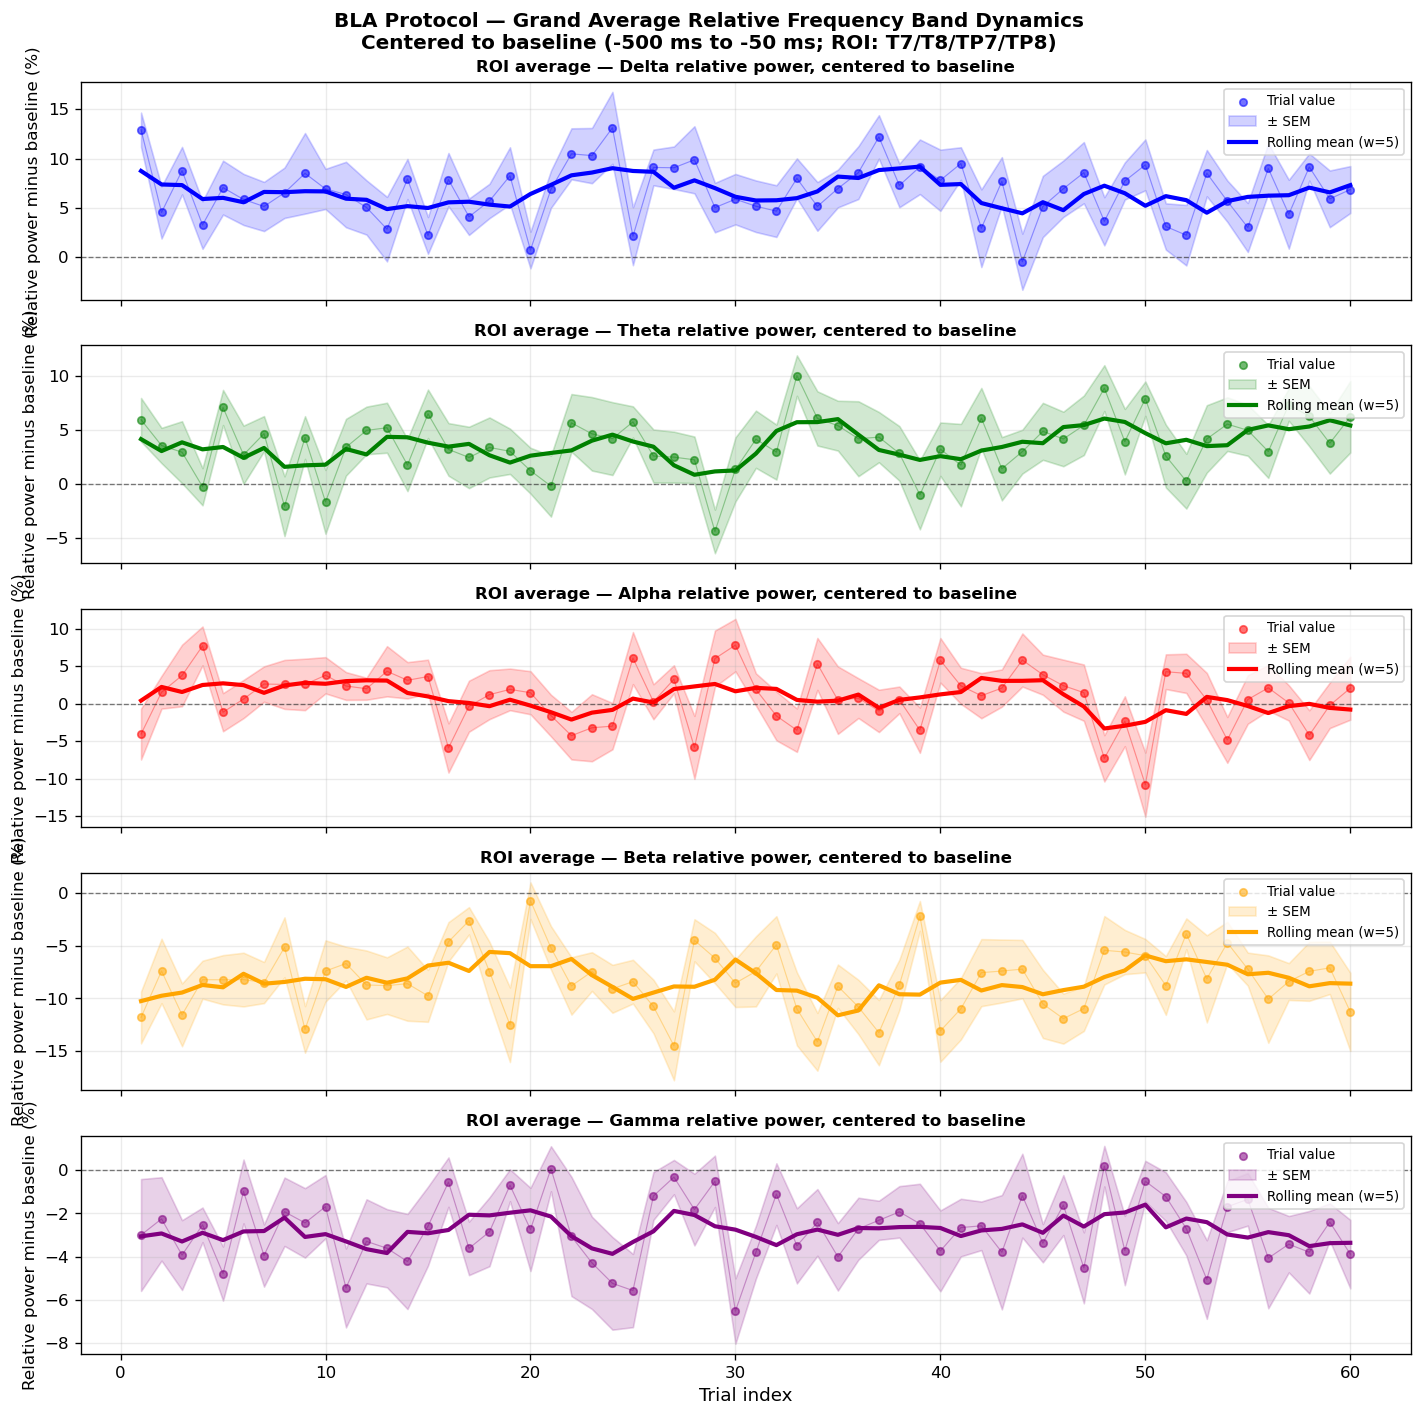

Figure saved: relative_frequency_dynamics_BLA_grand_average.png
Relative power is computed first, then centered by subtracting the baseline relative power.


In [10]:

# --- Relative power grand-average plots, centered to each trial's baseline relative power ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# IMPORTANT:
# Relative power is computed from the RAW absolute values first.
# Then we subtract the baseline relative power for the same trial and band.
all_relative_power_pivots = {}
relative_subject_tables = []

for subject_id in processed_subjects:
    power_pivot_raw = all_power_pivots_raw[subject_id].copy().reindex(columns=bands).reset_index(drop=True)
    baseline_pivot = all_baseline_power_pivots[subject_id].copy().reindex(columns=bands).reset_index(drop=True)

    relative_power_pivot = compute_relative_power_pivot(power_pivot_raw, bands)
    baseline_relative_pivot = compute_relative_power_pivot(baseline_pivot, bands)

    relative_power_centered = relative_power_pivot - baseline_relative_pivot

    all_relative_power_pivots[subject_id] = relative_power_centered

    temp = relative_power_centered.copy()
    temp["subject_id"] = subject_id
    temp["trial_idx"] = np.arange(1, len(temp) + 1)
    relative_subject_tables.append(temp)

relative_long = pd.concat(relative_subject_tables, ignore_index=True)
grand_relative_mean = relative_long.groupby("trial_idx")[bands].mean()
grand_relative_sem = relative_long.groupby("trial_idx")[bands].sem()

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

trial_idx = grand_relative_mean.index.values

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    values = grand_relative_mean[band].values
    errors = grand_relative_sem[band].values

    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    ax.fill_between(
        trial_idx,
        values - errors,
        values + errors,
        color=color,
        alpha=0.18,
        zorder=1,
        label='± SEM'
    )

    rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(
        trial_idx,
        rolling,
        color=color,
        linewidth=2.5,
        zorder=3,
        label=f'Rolling mean (w={ROLLING_WINDOW})'
    )

    ax.set_ylabel('Relative power minus baseline (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power, centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Relative Frequency Band Dynamics\nCentered to baseline ({BASELINE_LABEL}; ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average.png")
print("Relative power is computed first, then centered by subtracting the baseline relative power.")


# BLA Frequency Domain Relative Power 0-500ms

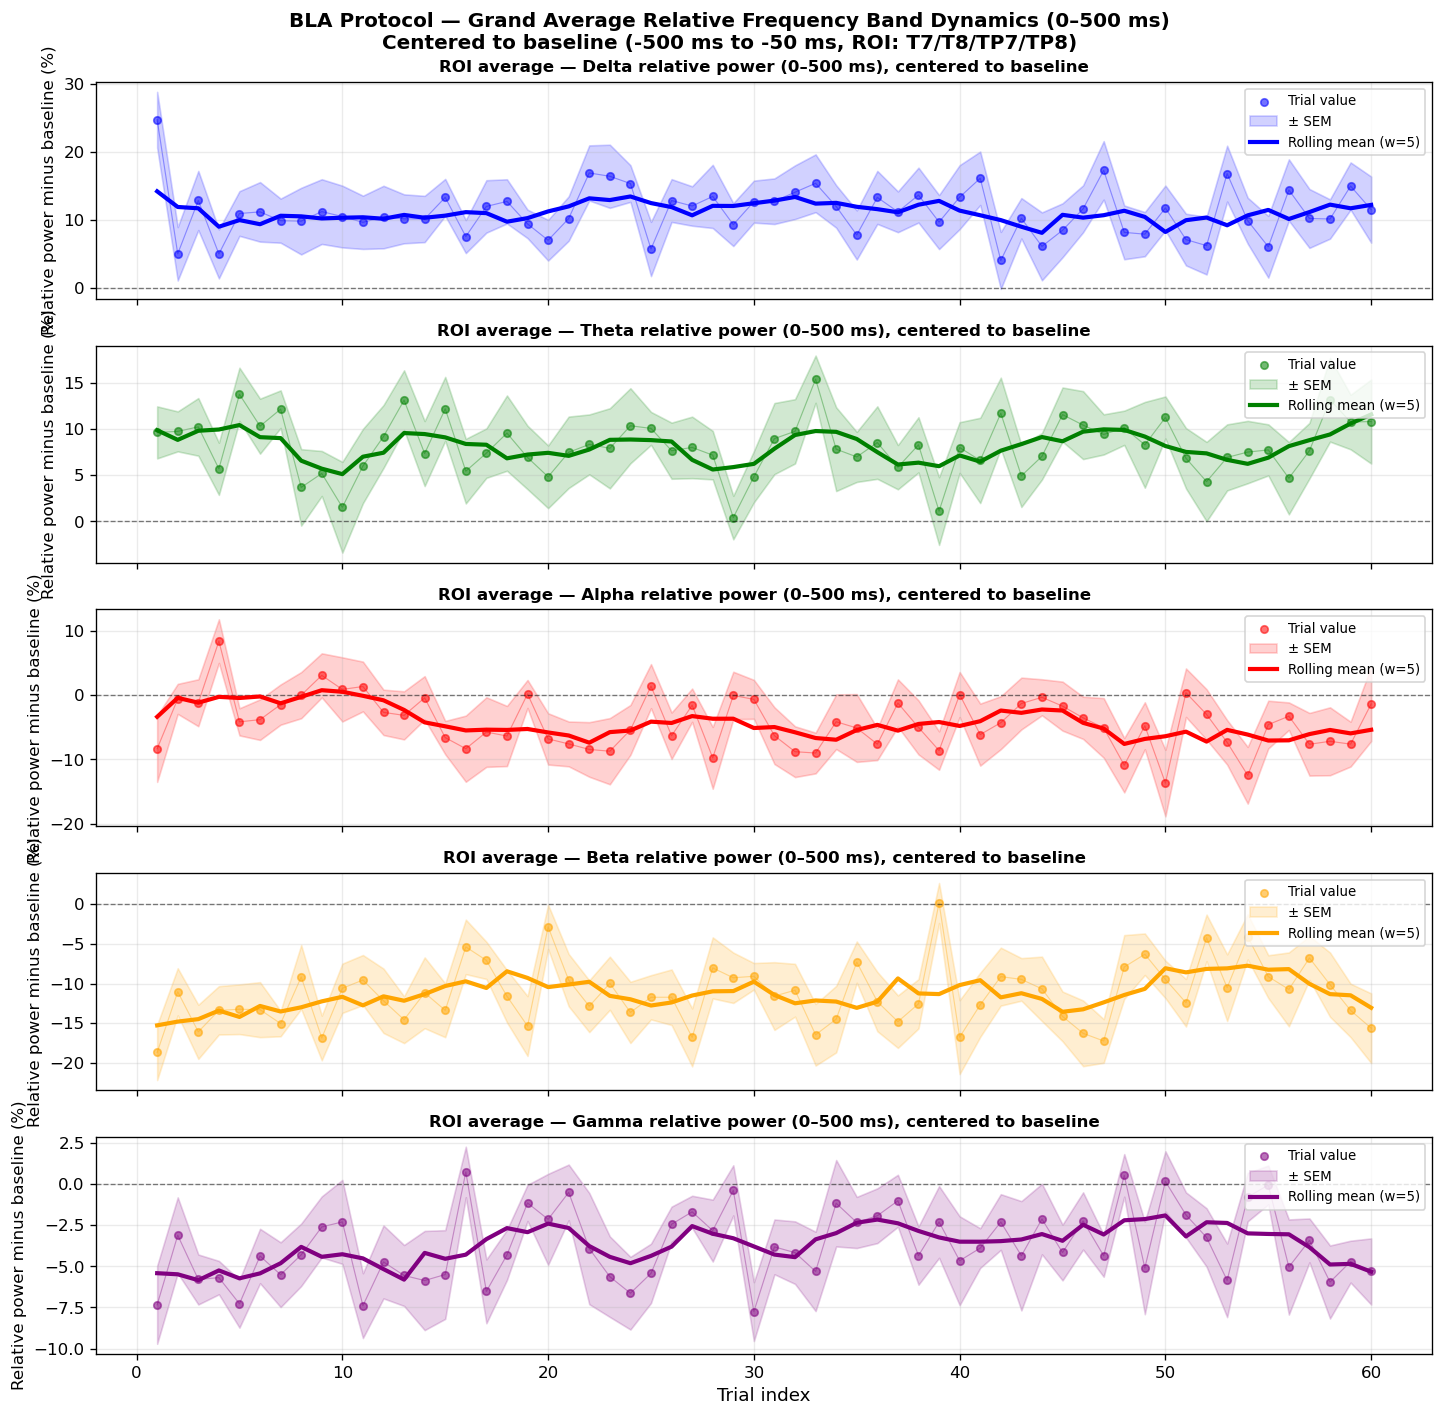

Figure saved: relative_frequency_dynamics_BLA_grand_average_0_500ms.png


In [11]:

# --- Relative frequency-domain power using only 0–500 ms, centered to baseline ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

all_relative_power_pivots_0_500ms = {}

for subject_id in processed_subjects_0_500ms:
    power_pivot_raw = all_power_pivots_raw_0_500ms[subject_id].copy().reindex(columns=bands)
    baseline_pivot = all_baseline_power_pivots_0_500ms[subject_id].copy().reindex(columns=bands)

    relative_power_pivot = compute_relative_power_pivot(power_pivot_raw, bands)
    baseline_relative_pivot = compute_relative_power_pivot(baseline_pivot, bands)

    relative_power_centered = relative_power_pivot - baseline_relative_pivot
    all_relative_power_pivots_0_500ms[subject_id] = relative_power_centered

grand_relative_power_0_500ms = {}
grand_relative_sem_0_500ms = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_0_500ms:
        relative_power_pivot = all_relative_power_pivots_0_500ms[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_0_500ms[band] = band_df.mean(axis=1)
        grand_relative_sem_0_500ms[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_0_500ms:
        values = grand_relative_power_0_500ms[band].values
        errors = grand_relative_sem_0_500ms[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus baseline (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power (0–500 ms), centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Relative Frequency Band Dynamics (0–500 ms)\nCentered to baseline ({BASELINE_LABEL}, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average_0_500ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average_0_500ms.png")


# BLA Frequency Domain Relative Power 500-1000ms

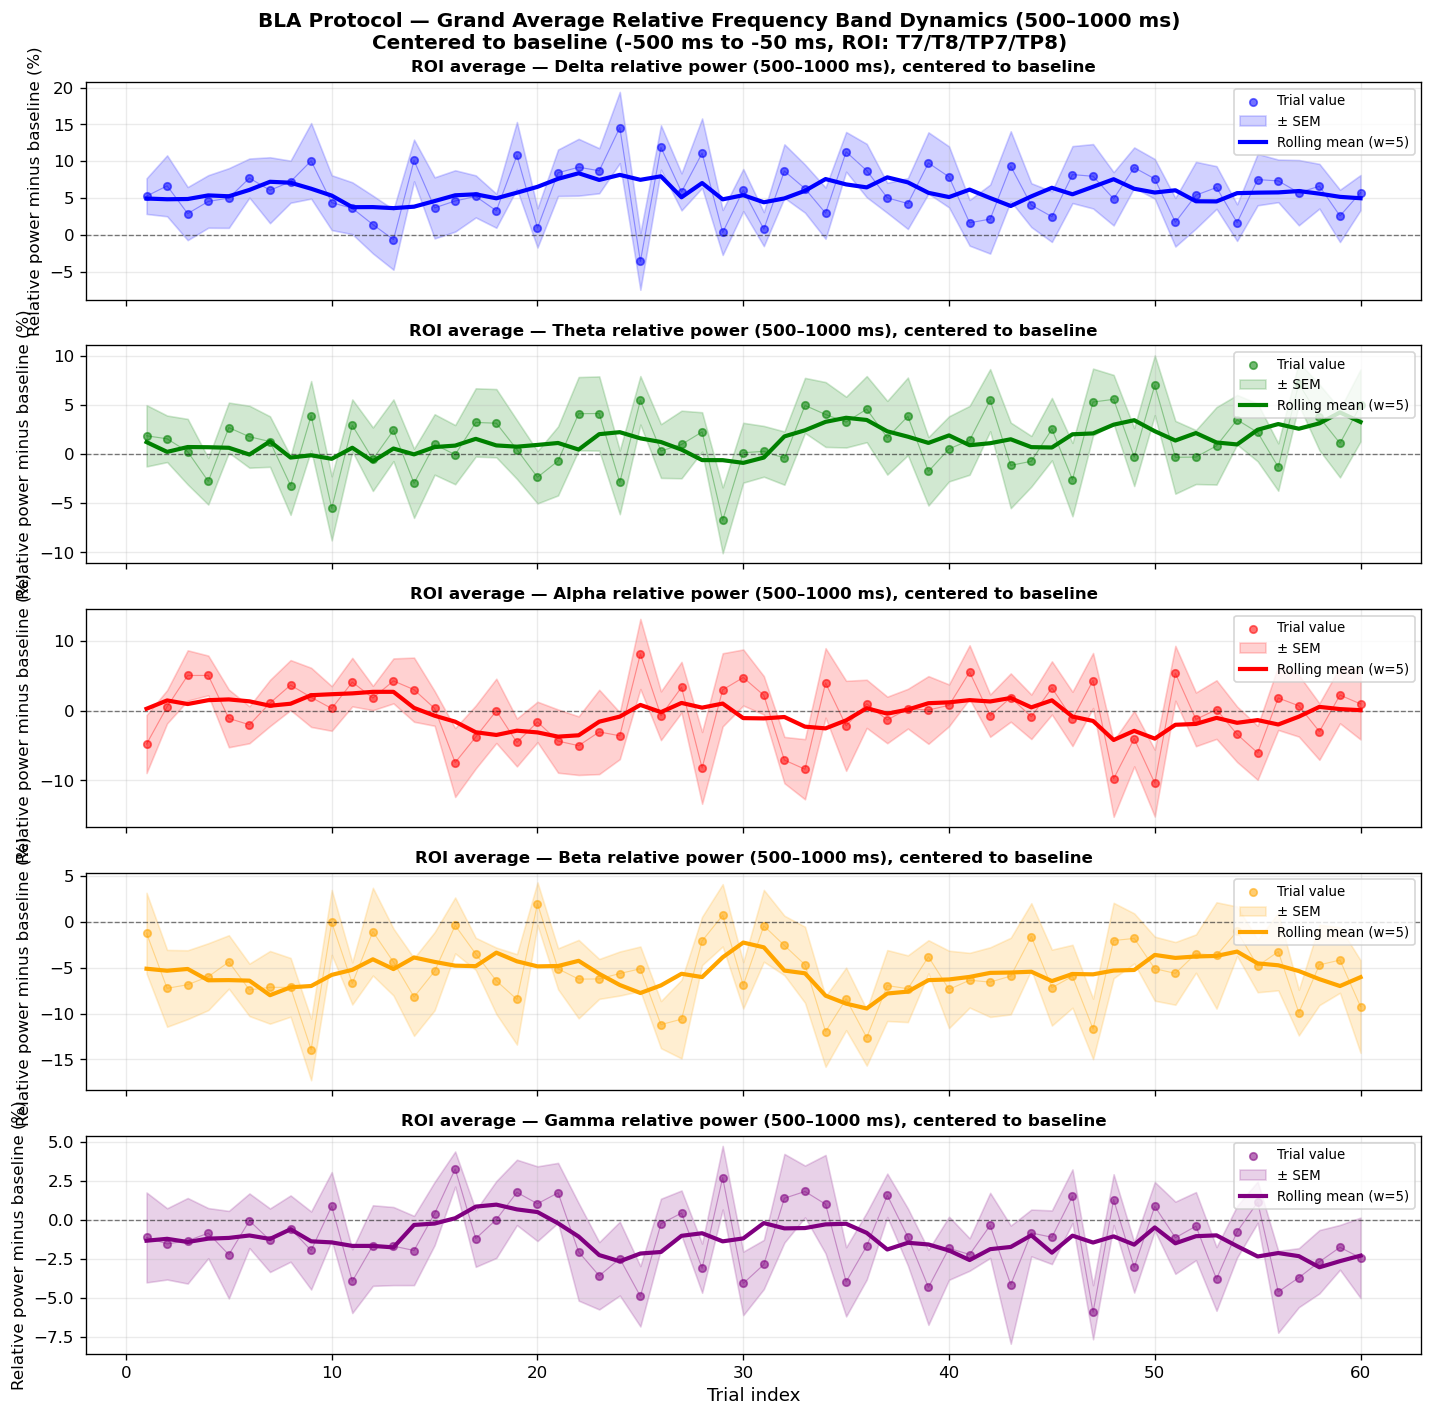

Figure saved: relative_frequency_dynamics_BLA_grand_average_500_1000ms.png


In [12]:

# --- Relative frequency-domain power using only 500–1000 ms, centered to baseline ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

all_relative_power_pivots_500_1000ms = {}

for subject_id in processed_subjects_500_1000ms:
    power_pivot_raw = all_power_pivots_raw_500_1000ms[subject_id].copy().reindex(columns=bands)
    baseline_pivot = all_baseline_power_pivots_500_1000ms[subject_id].copy().reindex(columns=bands)

    relative_power_pivot = compute_relative_power_pivot(power_pivot_raw, bands)
    baseline_relative_pivot = compute_relative_power_pivot(baseline_pivot, bands)

    relative_power_centered = relative_power_pivot - baseline_relative_pivot
    all_relative_power_pivots_500_1000ms[subject_id] = relative_power_centered

grand_relative_power_500_1000ms = {}
grand_relative_sem_500_1000ms = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_500_1000ms:
        relative_power_pivot = all_relative_power_pivots_500_1000ms[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_500_1000ms[band] = band_df.mean(axis=1)
        grand_relative_sem_500_1000ms[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_500_1000ms:
        values = grand_relative_power_500_1000ms[band].values
        errors = grand_relative_sem_500_1000ms[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus baseline (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power (500–1000 ms), centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Relative Frequency Band Dynamics (500–1000 ms)\nCentered to baseline ({BASELINE_LABEL}, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average_500_1000ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average_500_1000ms.png")


# BLA Time_Frequency Domain Absolute Power

In [13]:
# Import time-frequency functions
import mne
from mne.time_frequency import tfr_morlet

# Time-frequency analysis parameters
TF_N_CYCLES = 2.0
TF_FREQS = np.logspace(np.log10(1), np.log10(45), 20)  # 1–45 Hz, log-spaced

# Match the rest of the notebook
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
CONDITION = "BLA"
CHANNELS = "BLA"

print("Time-frequency analysis parameters:")
print(f"Frequencies: {TF_FREQS[0]:.1f} - {TF_FREQS[-1]:.1f} Hz ({len(TF_FREQS)} points)")
print(f"Wavelet cycles: {TF_N_CYCLES}")
print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")



Time-frequency analysis parameters:
Frequencies: 1.0 - 45.0 Hz (20 points)
Wavelet cycles: 2.0
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [14]:

import warnings
import contextlib
import io

# We keep both raw and centered time-frequency power.
# Raw is needed for computing relative power correctly later.
tf_power_dfs = {}
tf_power_pivots = {}
tf_full_power_pivots_raw = {}
tf_full_power_pivots_centered = {}
tf_processed_subjects = []
tf_failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Use the original signal in volts for MNE.
                # We do baseline-centering after extracting band power from the TFR.
                n_trials = len(epochs)
                ch_names = epochs.ch_names

                tfr_data = []
                for ch in ch_names:
                    tfr = tfr_morlet(
                        epochs.copy().pick([ch]),
                        freqs=TF_FREQS,
                        n_cycles=TF_N_CYCLES,
                        average=False,
                        return_itc=False,
                        verbose=False
                    )

                    # tfr.data has shape: trials x 1 channel x freqs x times.
                    # Remove the singleton channel dimension.
                    power = tfr.data.mean(axis=1)
                    tfr_data.append(power)

                # Average power across the ROI channels.
                roi_power = np.mean(tfr_data, axis=0)   # shape = trials x freqs x times

                # Collapse the frequency axis inside each named band.
                band_power_full_raw = {}
                for band, (fmin, fmax) in FREQ_BANDS.items():
                    freq_mask = (TF_FREQS >= fmin) & (TF_FREQS <= fmax)
                    if freq_mask.any():
                        band_power_full_raw[band] = roi_power[:, freq_mask, :].mean(axis=1)

                # Baseline-center each trial separately for each band.
                baseline_mask = (tfr.times >= BASELINE_TMIN) & (tfr.times <= BASELINE_TMAX)
                band_power_full_centered = {}
                for band, band_power in band_power_full_raw.items():
                    baseline_mean = band_power[:, baseline_mask].mean(axis=1, keepdims=True)
                    band_power_full_centered[band] = band_power - baseline_mean

                # Keep only post-stimulus times for the final plotted curves, matching the original structure.
                post_stim_mask = tfr.times >= 0
                times_post = tfr.times[post_stim_mask]

                tf_features = []
                tf_pivot = {}
                tf_full_raw_pivot = {}
                tf_full_centered_pivot = {}

                for band in FREQ_BANDS.keys():
                    if band in band_power_full_raw:
                        raw_post = band_power_full_raw[band][:, post_stim_mask]
                        centered_post = band_power_full_centered[band][:, post_stim_mask]

                        tf_full_raw_pivot[band] = pd.DataFrame(
                            band_power_full_raw[band],
                            index=np.arange(1, n_trials + 1),
                            columns=tfr.times * 1000
                        )

                        tf_full_centered_pivot[band] = pd.DataFrame(
                            band_power_full_centered[band],
                            index=np.arange(1, n_trials + 1),
                            columns=tfr.times * 1000
                        )

                        tf_pivot[band] = pd.DataFrame(
                            centered_post,
                            index=np.arange(1, n_trials + 1),
                            columns=times_post * 1000
                        )

                        for trial in range(n_trials):
                            for time_idx, time_val in enumerate(times_post):
                                tf_features.append({
                                    'trial': trial + 1,
                                    'time_ms': time_val * 1000,
                                    'band': band,
                                    'power_minus_baseline': centered_post[trial, time_idx]
                                })

                tf_df = pd.DataFrame(tf_features)

        tf_power_dfs[subject_id] = tf_df
        tf_power_pivots[subject_id] = tf_pivot
        tf_full_power_pivots_raw[subject_id] = tf_full_raw_pivot
        tf_full_power_pivots_centered[subject_id] = tf_full_centered_pivot
        tf_processed_subjects.append(subject_id)

    except Exception as e:
        tf_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_processed_subjects)
print(f"Time-frequency graphs are baseline-centered using {BASELINE_LABEL}.")

if tf_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Time-frequency graphs are baseline-centered using -500 ms to -50 ms.


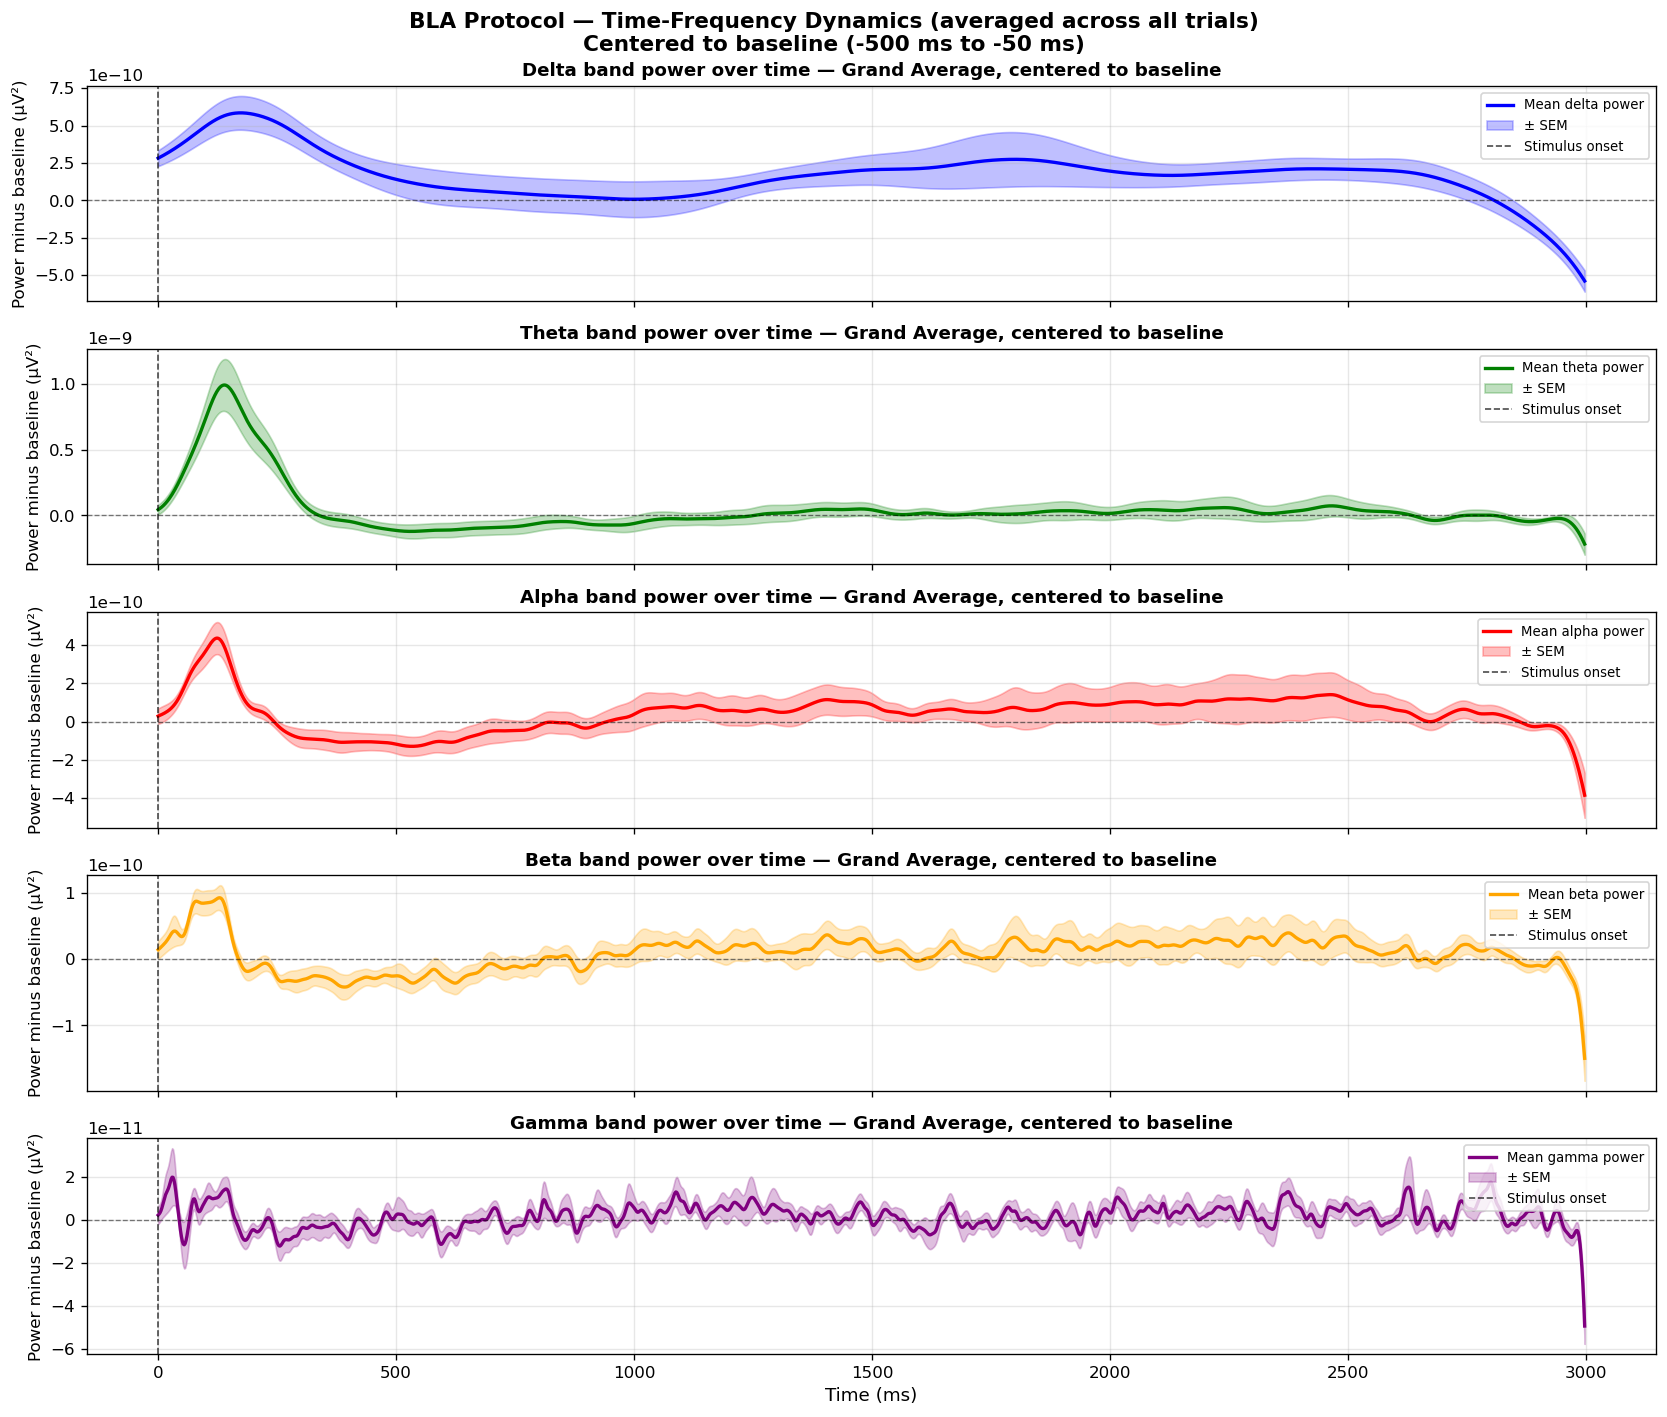

Figure saved: time_frequency_dynamics_BLA_grand_average.png


In [15]:

# Plot time-frequency power dynamics over time (grand average across subjects).
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_power = {}
grand_tf_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_processed_subjects:
        if subject_id in tf_power_pivots and band in tf_power_pivots[subject_id]:
            pivot_data = tf_power_pivots[subject_id][band]

            # Average across trials so each subject contributes one time course.
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_power[band] = band_df.mean(axis=1)
        grand_tf_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

first_subject = tf_processed_subjects[0]
available_bands = [band for band in bands if band in tf_power_pivots[first_subject]]
time_points = tf_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_power:
        mean_power = grand_tf_power[band].values
        errors = grand_tf_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.set_ylabel('Power minus baseline (µV²)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band power over time — Grand Average, centered to baseline',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Time-Frequency Dynamics (averaged across all trials)\nCentered to baseline ({BASELINE_LABEL})',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: time_frequency_dynamics_BLA_grand_average.png")


# BLA Time_Frequency Domain Relative Power

In [16]:

# Compute relative power for the time-frequency domain.
# As before, do NOT compute relative power from already centered absolute power.
# First compute relative power from raw absolute power, then subtract baseline-relative power.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

tf_relative_power_dfs = {}
tf_relative_power_pivots = {}
tf_relative_processed_subjects = []
tf_relative_failed_subjects = []

for subject_id in tf_processed_subjects:
    try:
        tf_raw_pivot = tf_full_power_pivots_raw[subject_id]

        available_bands = [band for band in bands if band in tf_raw_pivot]

        if not available_bands:
            raise ValueError("No frequency bands found in tf_full_power_pivots_raw for this subject.")

        # Total raw power at each trial x time point across all available bands.
        total_power_at_time = None
        for band in available_bands:
            band_pivot = tf_raw_pivot[band].copy()
            if total_power_at_time is None:
                total_power_at_time = band_pivot.copy()
            else:
                total_power_at_time = total_power_at_time + band_pivot

        relative_tf_pivot_raw = {}
        for band in available_bands:
            band_pivot = tf_raw_pivot[band].copy()
            relative_tf_pivot_raw[band] = band_pivot.div(total_power_at_time) * 100

        # Baseline-center the relative power in time for each trial.
        baseline_mask = (total_power_at_time.columns >= BASELINE_TMIN * 1000) & (total_power_at_time.columns <= BASELINE_TMAX * 1000)
        relative_tf_pivot_centered = {}
        tf_relative_features = []

        for band in available_bands:
            band_relative = relative_tf_pivot_raw[band].copy()
            baseline_relative = band_relative.loc[:, baseline_mask].mean(axis=1)
            centered = band_relative.subtract(baseline_relative, axis=0)
            centered_post = centered.loc[:, centered.columns >= 0]

            relative_tf_pivot_centered[band] = centered_post

            for trial in centered_post.index:
                for time_point in centered_post.columns:
                    tf_relative_features.append({
                        'trial': trial,
                        'time_ms': time_point,
                        'band': band,
                        'relative_power_minus_baseline': centered_post.loc[trial, time_point]
                    })

        tf_relative_df = pd.DataFrame(tf_relative_features)

        tf_relative_power_dfs[subject_id] = tf_relative_df
        tf_relative_power_pivots[subject_id] = relative_tf_pivot_centered
        tf_relative_processed_subjects.append(subject_id)

    except Exception as e:
        tf_relative_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_relative_processed_subjects)

if tf_relative_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_relative_failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


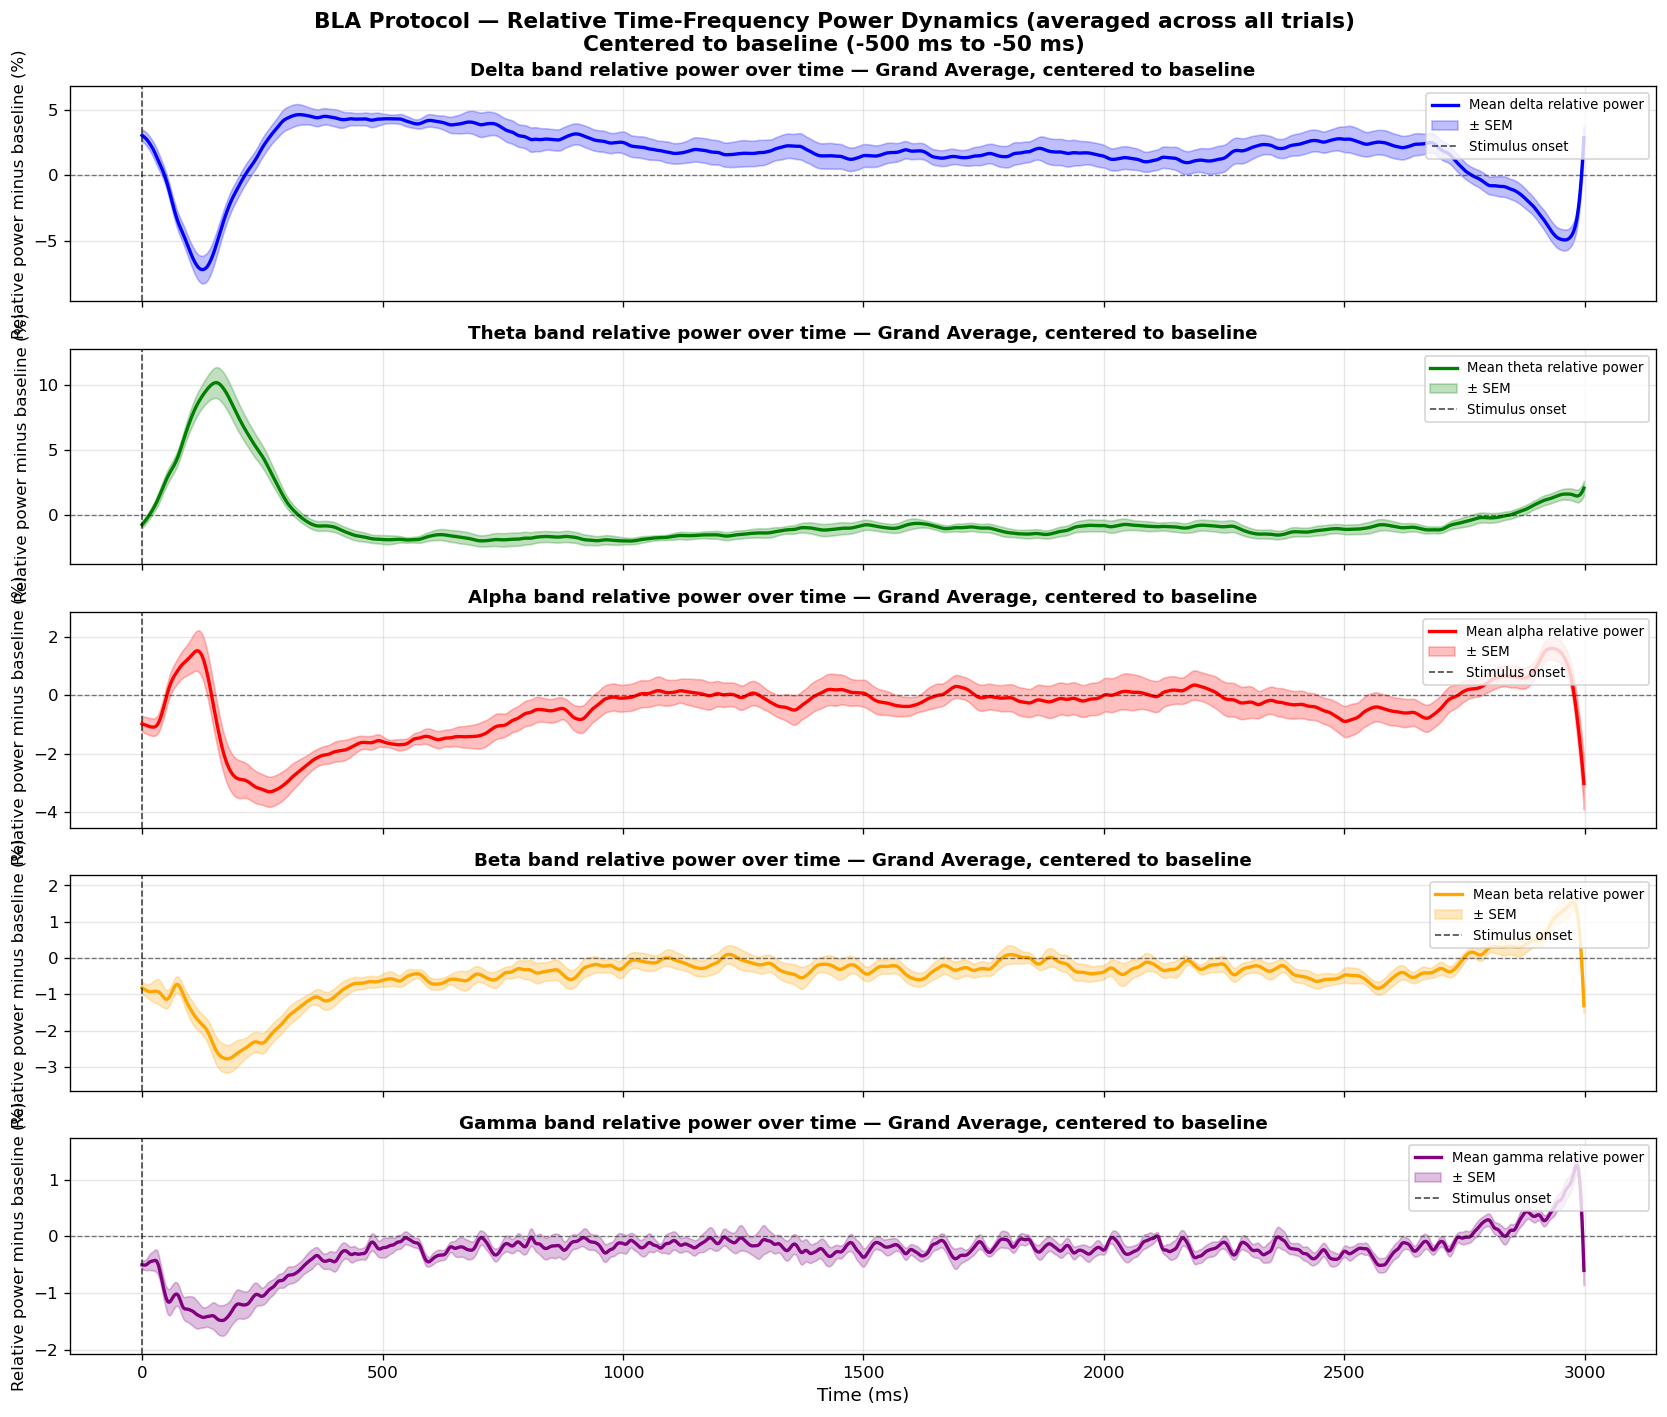

Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png

Average baseline-centered relative power across time (Grand Average):
Delta: 1.6%
Theta: -0.5%
Alpha: -0.5%
Beta: -0.5%
Gamma: -0.3%


In [17]:

# Plot relative time-frequency power dynamics over time (grand average across subjects).
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_relative_power = {}
grand_tf_relative_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_relative_processed_subjects:
        if subject_id in tf_relative_power_pivots and band in tf_relative_power_pivots[subject_id]:
            pivot_data = tf_relative_power_pivots[subject_id][band]

            # Average across trials so each subject contributes one time course.
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_relative_power[band] = band_df.mean(axis=1)
        grand_tf_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

first_subject = tf_relative_processed_subjects[0]
available_bands = [band for band in bands if band in tf_relative_power_pivots[first_subject]]
time_points = tf_relative_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_relative_power:
        mean_power = grand_tf_relative_power[band].values
        errors = grand_tf_relative_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

        min_val = np.min(mean_power - errors)
        max_val = np.max(mean_power + errors)
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

    ax.set_ylabel('Relative power minus baseline (%)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band relative power over time — Grand Average, centered to baseline',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Relative Time-Frequency Power Dynamics (averaged across all trials)\nCentered to baseline ({BASELINE_LABEL})',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png")

print("\nAverage baseline-centered relative power across time (Grand Average):")
for band in bands:
    if band in grand_tf_relative_power:
        avg_relative_power = grand_tf_relative_power[band].mean()
        print(f"{band.capitalize()}: {avg_relative_power:.1f}%")


# Filter vs No Filter Comparison

In [18]:

import warnings
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GOAL:
# Compare grand-average band power across trials for:
#   1) unfiltered EEG data
#   2) filtered EEG data
# while centering BOTH curves to the same requested baseline window.
# ------------------------------------------------------------

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = {{
    'delta': 'blue',
    'theta': 'green',
    'alpha': 'red',
    'beta': 'orange',
    'gamma': 'purple'
}}

FILTER_BAND = "delta_gamma"

all_power_pivots_unfiltered_raw = {{}}
all_power_pivots_unfiltered_centered = {{}}
all_power_pivots_filtered_raw = {{}}
all_power_pivots_filtered_centered = {{}}

processed_unfiltered = []
processed_filtered = []
failed_unfiltered = []
failed_filtered = []

for subject_id in SUBJECTS:

    # ---------------------------
    # A) UNFILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs_unf = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS
                )

        epochs_unf_baseline = epochs_unf.copy().crop(tmin=BASELINE_TMIN, tmax=BASELINE_TMAX)

        power_df_unf, _ = compute_frequency_power(epochs_unf, fmin=0.5, fmax=45)
        baseline_df_unf, _ = compute_frequency_power(epochs_unf_baseline, fmin=0.5, fmax=45)

        power_pivot_unf = power_df_unf.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)
        baseline_pivot_unf = baseline_df_unf.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        centered_unf = power_pivot_unf - baseline_pivot_unf

        all_power_pivots_unfiltered_raw[subject_id] = power_pivot_unf
        all_power_pivots_unfiltered_centered[subject_id] = centered_unf
        processed_unfiltered.append(subject_id)

    except Exception as e:
        failed_unfiltered.append((subject_id, str(e)))

    # ---------------------------
    # B) FILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs_filt = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band=FILTER_BAND
                )

        epochs_filt_baseline = epochs_filt.copy().crop(tmin=BASELINE_TMIN, tmax=BASELINE_TMAX)

        power_df_filt, _ = compute_frequency_power(epochs_filt, fmin=0.5, fmax=45)
        baseline_df_filt, _ = compute_frequency_power(epochs_filt_baseline, fmin=0.5, fmax=45)

        power_pivot_filt = power_df_filt.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)
        baseline_pivot_filt = baseline_df_filt.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        centered_filt = power_pivot_filt - baseline_pivot_filt

        all_power_pivots_filtered_raw[subject_id] = power_pivot_filt
        all_power_pivots_filtered_centered[subject_id] = centered_filt
        processed_filtered.append(subject_id)

    except Exception as e:
        failed_filtered.append((subject_id, str(e)))

common_subjects = sorted(set(processed_unfiltered) & set(processed_filtered))

print("Processed successfully in both:", common_subjects)

if failed_unfiltered:
    print("\nUnfiltered failed:")
    for subject_id, err in failed_unfiltered:
        print(f"Subject {subject_id}: {err}")

if failed_filtered:
    print("\nFiltered failed:")
    for subject_id, err in failed_filtered:
        print(f"Subject {subject_id}: {err}")

grand_power_unfiltered = {{}}
grand_power_filtered = {{}}

for band in bands:
    band_trials_unf = []
    band_trials_filt = []

    for subject_id in common_subjects:
        pivot_unf = all_power_pivots_unfiltered_centered[subject_id]
        pivot_filt = all_power_pivots_filtered_centered[subject_id]

        if band in pivot_unf.columns:
            band_trials_unf.append(pivot_unf[band].reset_index(drop=True))

        if band in pivot_filt.columns:
            band_trials_filt.append(pivot_filt[band].reset_index(drop=True))

    if band_trials_unf:
        grand_power_unfiltered[band] = pd.concat(band_trials_unf, axis=1).mean(axis=1)

    if band_trials_filt:
        grand_power_filtered[band] = pd.concat(band_trials_filt, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    color = colors[band]

    if band in grand_power_unfiltered:
        values_unf = grand_power_unfiltered[band].values
        trial_idx_unf = np.arange(1, len(values_unf) + 1)

        ax.scatter(trial_idx_unf, values_unf, color=color, s=16, alpha=0.18, zorder=1)
        ax.plot(trial_idx_unf, values_unf, color=color, linewidth=0.8, alpha=0.22, zorder=1)

        rolling_unf = pd.Series(values_unf).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx_unf, rolling_unf,
            color=color, linewidth=2.2, alpha=0.9, linestyle='--',
            zorder=3, label='Unfiltered'
        )

    if band in grand_power_filtered:
        values_filt = grand_power_filtered[band].values
        trial_idx_filt = np.arange(1, len(values_filt) + 1)

        ax.scatter(trial_idx_filt, values_filt, color='black', s=16, alpha=0.15, zorder=2)
        ax.plot(trial_idx_filt, values_filt, color='black', linewidth=0.8, alpha=0.20, zorder=2)

        rolling_filt = pd.Series(values_filt).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx_filt, rolling_filt,
            color='black', linewidth=2.4, zorder=4, label=f'Filtered ({FILTER_BAND})'
        )

    ax.set_ylabel('Power minus baseline (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power, centered to baseline', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    f'BLA Protocol — Grand Average Frequency Domain Dynamics\nUnfiltered vs Filtered, centered to baseline ({BASELINE_LABEL})',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_filtered_vs_unfiltered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png")


TypeError: unhashable type: 'dict'